$$
\begin{array}{c}
\textbf{Linear Regression - Spring 2026}\\\\
\textit{Center for Data Science, New York University} \\\\
\textit{March 27, 2026}\\\\\
\text{ Prepared by: Vivek Kumar Agarwal}\\\\
\textbf{Recitation 7: Linear Regression}
\end{array}
$$

---

![Linear Regression](../figures/LR_lab7_image1.png)

---

# Recitation 6: Feature Engineering & Causal MLR

## Today's Outline

### MLR 2 — Feature Engineering
1. **Polynomial Regression** — capturing non-linearities with powers of X; overfitting; R² vs MSE
2. **Train / Validation / Test Splits** — why we need a 3-way split when choosing hyperparameters
3. **Binning** — bin indicators, recovering sample means, bias/variance tradeoff
4. **Polynomials vs Binning** — when to use each
5. **Interaction Terms** — modeling relationships *between* predictors; Income × Student example

### MLR 3 — Causality & Controls
6. **Conditional Independence** — X ⊥ Y | Z; height, reading, and age
7. **Causal MLR with Controls** — when and how controls let us estimate causal effects
8. **Omitted Variable Bias (OVB)** — what we're actually estimating when we omit a variable; more controls ≠ more causal

### OLS for MLR
9. **OLS in Matrix Form** — extending OLS to multiple regressors using matrix algebra
10. **Properties of the MLR OLS Estimator** — unbiasedness, consistency, variance

---

## 1. Polynomial Regression

### Motivation
Suppose the true CEF $E[Y|X]$ is **non-linear** w.r.t. X.
A simple SLR model will miss this — but MLR lets us capture it
by engineering new features from X itself.

### The Idea
From calculus, any smooth function can be approximated by polynomials.
A **k-th order polynomial regression** is:

$$Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \dots + \beta_k X^k + \varepsilon$$

This is still **linear** in the parameters $\beta$ — so OLS applies as normal.
The features $X, X^2, \dots, X^k$ are just new columns in our data matrix.

### The Tradeoff
| | Bias | Variance |
|---|---|---|
| **Low k** | High (misses non-linearity) | Low |
| **High k** | Low (flexible fit) | High (overfitting risk) |

Higher k fits the training data better — but risks **overfitting**:
the model starts chasing the quirks of the sample rather than the true underlying pattern.

### R² is not enough
R² always increases with more regressors — so a 50th degree polynomial
will always *look* better in-sample. We need **out-of-sample MSE** to
catch overfitting — which is why train/test splits matter.

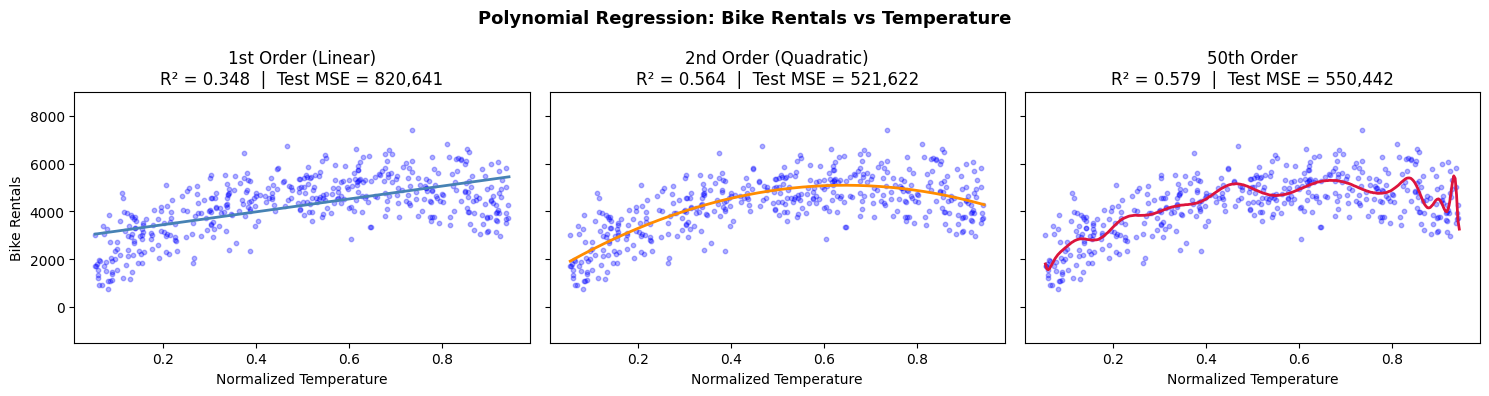

Degree            Test MSE
1                  820,641
2                  521,622
50                 550,442

R² always increases - misleading
Test MSE catches the 50th degree problem


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm

# ── Simulate bike rental data (mirrors the slide pattern) ──
np.random.seed(42)
n = 500
X = np.random.uniform(0.05, 0.95, n)
# Inverted U-shape: rentals peak around temp=0.6
y = -8000*(X - 0.65)**2 + 5000 + np.random.randn(n) * 800
y = np.clip(y, 0, 8000)

# Train/test split (90/10 as in slides)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# ── Fit 1st, 2nd, 50th degree polynomials ──
degrees = [1, 2, 50]
models, mses = {}, {}
x_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_tr = poly.fit_transform(X_train.reshape(-1, 1))
    X_te = poly.transform(X_test.reshape(-1, 1))
    X_pl = poly.transform(x_plot)
    m = LinearRegression().fit(X_tr, y_train)
    models[d] = (m, poly, X_pl)
    mses[d] = mean_squared_error(y_test, m.predict(X_te))

# ── Plot ──
titles = {1: '1st Order (Linear)', 2: '2nd Order (Quadratic)', 50: '50th Order'}
colors = {1: 'steelblue', 2: 'darkorange', 50: 'crimson'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, d in zip(axes, degrees):
    m, poly, X_pl = models[d]
    ax.scatter(X_train, y_train, color='blue', alpha=0.3, s=10)
    ax.plot(x_plot, m.predict(X_pl), color=colors[d], linewidth=2)
    r2 = m.score(poly.transform(X_train.reshape(-1, 1)), y_train)
    ax.set_title(f'{titles[d]}\nR² = {r2:.3f}  |  Test MSE = {mses[d]:,.0f}')
    ax.set_xlabel('Normalized Temperature')
    ax.set_ylim(-1500, 9000)

axes[0].set_ylabel('Bike Rentals')
plt.suptitle('Polynomial Regression: Bike Rentals vs Temperature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── MSE Table ──
print("=" * 40)
print(f"{'Degree':<10} {'Test MSE':>15}")
print("=" * 40)
for d in degrees:
    print(f"{d:<10} {mses[d]:>15,.0f}")
print("=" * 40)
print("\nR² always increases - misleading")
print("Test MSE catches the 50th degree problem")

## 2. Train / Validation / Test Splits

### The Problem
R² always increases as we add more polynomial terms — so we
can't use in-sample fit to choose the "right" degree k.
We need **out-of-sample** evaluation.

### Two-Way Split (Train / Test)
We already know this:
- **Training set** — fit the model, estimate $\hat{\beta}$
- **Test set** — evaluate out-of-sample MSE

But there's a subtle problem: if we use the test set to *choose* k,
the test set is now influencing our model — it's no longer a clean evaluation.

### The Fix: Three-Way Split
When we need to choose a **hyperparameter** (like polynomial degree k),
we introduce a third split:

$$\text{All Data} \rightarrow \begin{cases} \text{Training Set} & \text{fit the model} \\ \text{Validation Set} & \text{compare models, pick best } k \\ \text{Test Set} & \text{final honest evaluation — used once, at the very end} \end{cases}$$

### Key Distinction
| | **Parameter** | **Hyperparameter** |
|---|---|---|
| Example | $\beta_0, \beta_1, \dots, \beta_k$ | degree $k$ itself |
| Chosen by | OLS (minimises SSR) | us, using validation set |

### Typical Split
80% training — 10% validation — 10% test

> The test set must have **nothing to do** with model formation.
> The moment we use it to select a model, it becomes a second validation set
> and our final MSE estimate is no longer honest.

---

## 3. Binning

### The Idea
Instead of fitting a smooth polynomial, we can divide X into
discrete **bins** and estimate the average Y within each bin.

For $k$ bins over $X \in [a, b]$, define indicator variables:

$$B_j = \begin{cases} 1 & \text{if } X \text{ falls in bin } j \\ 0 & \text{otherwise} \end{cases}$$

Then run:
$$Y = \beta_1 B_1 + \beta_2 B_2 + \dots + \beta_k B_k + \varepsilon$$

> **No constant!** The bin indicators already partition the full
> sample — including a constant causes perfect multicollinearity.
> Alternatively, drop one bin and include a constant (it becomes the reference category).

### What Do the Coefficients Mean?
$$\hat{\beta}_j = \bar{Y}_j \quad \text{(sample mean of Y within bin } j\text{)}$$

Each coefficient is just the **average outcome** among observations in that bin.
This makes binning coefficients very easy to interpret.

### Bias / Variance Tradeoff
| | Bias | Variance |
|---|---|---|
| **Few bins (small k)** | High — misses within-bin variation | Low — many obs per bin |
| **Many bins (large k)** | Low — captures fine detail | High — few obs per bin |

As $k \to \infty$, binning traces out the exact shape of $E[Y|X]$ —
but each bin mean is estimated from almost no data.
This is the same overfitting logic as polynomials, just a different form.

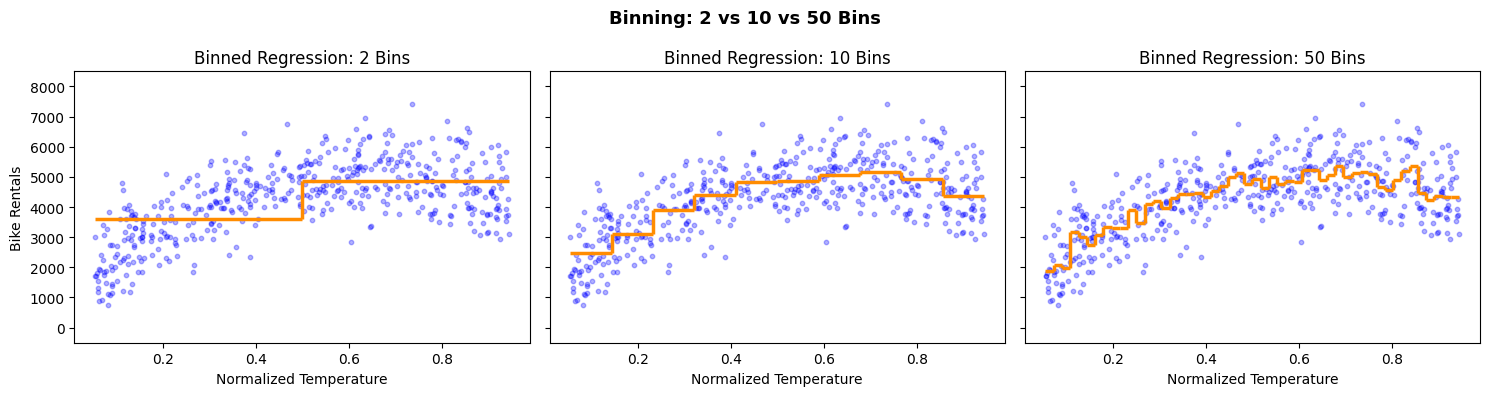

In [ ]:
# ── Binning Regression on Bike Data ──

# Reuse simulated data from Cell 3
np.random.seed(42)
n = 500
X = np.random.uniform(0.05, 0.95, n)
y = -8000*(X - 0.65)**2 + 5000 + np.random.randn(n) * 800
y = np.clip(y, 0, 8000)

def binned_regression(X, y, k):
    """Create bin indicators and fit binned regression."""
    bins = np.linspace(X.min(), X.max(), k + 1)
    bin_indices = np.digitize(X, bins[1:-1])  # assigns each obs to a bin
    
    # Create indicator matrix (no constant)
    X_binned = np.zeros((len(X), k))
    for i in range(k):
        X_binned[bin_indices == i, i] = 1
    
    m = LinearRegression(fit_intercept=False).fit(X_binned, y)
    
    # For plotting: predict at bin midpoints
    bin_mids = (bins[:-1] + bins[1:]) / 2
    y_pred = m.coef_
    
    return bins, bin_mids, y_pred

# ── Plot 2, 10, 50 bins ──
k_vals = [2, 10, 50]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, k in zip(axes, k_vals):
    bins, mids, y_pred = binned_regression(X, y, k)
    
    ax.scatter(X, y, color='blue', alpha=0.3, s=10)
    
    # Draw staircase
    for i in range(k):
        ax.hlines(y_pred[i], bins[i], bins[i+1],
                  color='darkorange', linewidth=2.5)
        if i < k - 1:
            ax.vlines(bins[i+1], y_pred[i], y_pred[i+1],
                      color='darkorange', linewidth=2.5)
    
    ax.set_title(f'Binned Regression: {k} Bins')
    ax.set_xlabel('Normalized Temperature')
    ax.set_ylim(-500, 8500)

axes[0].set_ylabel('Bike Rentals')
plt.suptitle('Binning: 2 vs 10 vs 50 Bins', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Polynomials vs Binning

Both approaches capture non-linearities — but they have different strengths:

| | **Polynomial Regression** | **Binning** |
|---|---|---|
| **Fit** | Smoother, fewer regressors needed | Staircase shape, needs many bins for detail |
| **Edge behavior** | Can go wild at the extremes of X | Well-behaved by construction |
| **Interpretability** | Harder — coefficients aren't intuitive | Easy — each $\hat{\beta}_j$ is a local mean |
| **Best for** | Prediction tasks | Descriptive / causal tasks |

> **Rule of thumb:** if you just want your model to predict well and don't
> need to "think about" the coefficients - polynomials.
> If you want to understand *what's going on* - binning.

---

## 5. Interaction Terms

### Motivation
So far, features enter the model **separately** — each predictor has its
own coefficient regardless of the others. But what if the relationship
between X and Y **depends on** another variable?

### The Setup
Predicting credit card **Balance** using **Income** and **Student** status:

$$\text{Balance} = \beta_0 + \beta_1 \text{Income} + \beta_2 \text{Student} + \varepsilon$$

- $\beta_1$ — general income effect on balance
- $\beta_2$ — average difference in balance between students and non-students

But this forces **the same income slope** on both groups.

### Adding an Interaction Term
$$\text{Balance} = \beta_0 + \beta_1 \text{Income} + \beta_2 \text{Student} + \beta_3 \text{Income} \times \text{Student} + \varepsilon$$

Now the slope on income **differs by group**:
- Among **non-students** (Student = 0): slope on income $= \beta_1$
- Among **students** (Student = 1): slope on income $= \beta_1 + \beta_3$

So $\beta_3$ captures the **difference in slopes** between the two groups.
If students' balances depend less on income (e.g. due to parental support
or scholarships), we'd expect $\beta_3 < 0$.

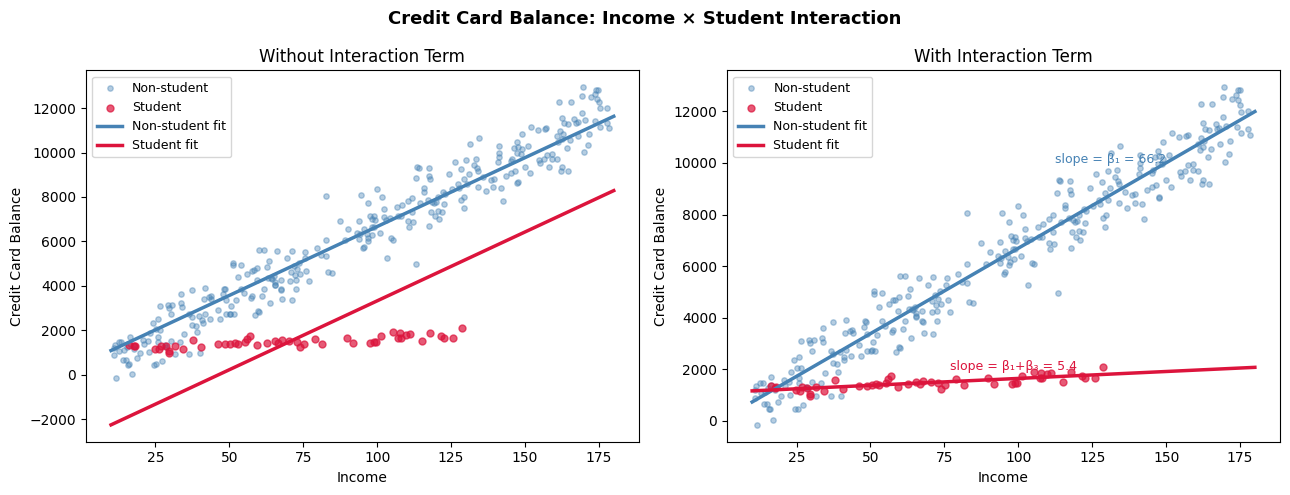

Without interaction:
  Balance = 473.2 + 62.0·Income + -3342.7·Student

With interaction:
  Balance = 72.4 + 66.2·Income + 1038.0·Student + -60.9·Income×Student

  Non-student income slope : β₁        = 66.2
  Student income slope     : β₁ + β₃   = 5.4


In [ ]:

# ── Simulate Credit Card Data ──
np.random.seed(42)
n_nonstudent = 300
n_student = 50

# Non-students: strong positive income effect
income_ns = np.random.uniform(10, 180, n_nonstudent)
balance_ns = 200 + 65 * income_ns + np.random.randn(n_nonstudent) * 800

# Students: weak income effect (flatter slope)
income_s = np.random.uniform(10, 130, n_student)
balance_s = 1100 + 5 * income_s + np.random.randn(n_student) * 150

# ── Combine into one dataset ──
income  = np.concatenate([income_ns, income_s])
balance = np.concatenate([balance_ns, balance_s])
student = np.array([0]*n_nonstudent + [1]*n_student)

# ── Model WITHOUT interaction ──
X_no = np.column_stack([income, student])
m_no = LinearRegression().fit(X_no, balance)
b0, b1, b2 = m_no.intercept_, m_no.coef_[0], m_no.coef_[1]

# ── Model WITH interaction ──
X_int = np.column_stack([income, student, income * student])
m_int = LinearRegression().fit(X_int, balance)
c0, c1, c2, c3 = m_int.intercept_, *m_int.coef_

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x_line = np.linspace(10, 180, 200)

for ax, title, ns_line, s_line in zip(
    axes,
    ['Without Interaction Term', 'With Interaction Term'],
    [b0 + b1*x_line,              c0 + c1*x_line],
    [b0 + b2 + b1*x_line,         c0 + c2 + (c1+c3)*x_line]
):
    ax.scatter(income_ns, balance_ns, color='steelblue', alpha=0.4,
               s=15, label='Non-student')
    ax.scatter(income_s,  balance_s,  color='crimson',   alpha=0.7,
               s=25, label='Student')
    ax.plot(x_line, ns_line, color='steelblue', linewidth=2.5,
            label=f'Non-student fit')
    ax.plot(x_line, s_line,  color='crimson',   linewidth=2.5,
            label=f'Student fit')
    ax.set_xlabel('Income')
    ax.set_ylabel('Credit Card Balance')
    ax.set_title(title)
    ax.legend(fontsize=9)

# Annotate slopes on the interaction plot
axes[1].annotate(f'slope = β₁ = {c1:.1f}',
                 xy=(150, c0 + c1*150), fontsize=9,
                 color='steelblue', ha='right')
axes[1].annotate(f'slope = β₁+β₃ = {c1+c3:.1f}',
                 xy=(120, c0 + c2 + (c1+c3)*120 + 200), fontsize=9,
                 color='crimson', ha='right')

plt.suptitle('Credit Card Balance: Income × Student Interaction',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Print coefficients ──
print("Without interaction:")
print(f"  Balance = {b0:.1f} + {b1:.1f}·Income + {b2:.1f}·Student\n")
print("With interaction:")
print(f"  Balance = {c0:.1f} + {c1:.1f}·Income + {c2:.1f}·Student + {c3:.1f}·Income×Student")
print(f"\n  Non-student income slope : β₁        = {c1:.1f}")
print(f"  Student income slope     : β₁ + β₃   = {c1+c3:.1f}")

---

## 6. Conditional Independence

### Independence (Recap)
Two variables X and Y are **independent** if:
$$P(X \in A, Y \in B) = P(X \in A) \cdot P(Y \in B)$$
i.e. knowing X tells you nothing about Y.

### Conditional Independence
Sometimes X and Y are **not** independent — but they become
independent once we account for a third variable Z:
$$X \perp Y \mid Z$$
$$P(X \in A, Y \in B \mid Z) = P(X \in A \mid Z) \cdot P(Y \in B \mid Z)$$

An equivalent and useful implication:
$$E[Y \mid X, Z] = E[Y \mid Z]$$
Once we know Z, also knowing X doesn't change our best guess at Y.

### Intuition: Height and Reading Ability
- **Unconditionally:** height and reading ability are *not* independent
  — babies are short and can't read; adults are tall and can read
- **Conditionally on Age:**
$$P(\text{can read} \mid \text{Age} = 20, \text{Height}) = P(\text{can read} \mid \text{Age} = 20)$$
Among 20-year-olds, height tells you nothing about reading ability.

The key intuition: **two variables are conditionally independent if
they are independent within sub-populations defined by Z.**

### Why Does This Matter for Regression?
Conditional independence is the key assumption that allows us to use
**control variables** to estimate causal effects — as we'll see next.

---

## 7. Causal MLR with Controls

### The Problem
Suppose the true causal model is:
$$Y = \alpha_0 + \alpha_1 X + U$$
but $E[XU] \neq 0$ — so SLR gives us a biased estimate of $\alpha_1$.

### The Fix: A Control Variable
Suppose we have some variable $C$ such that:
$$U \perp X \mid C \quad \Rightarrow \quad E[U \mid X, C] = E[U \mid C]$$
i.e. once we account for $C$, $X$ is no longer correlated with the error.

Further assume $E[U \mid C]$ is **linear**:
$$E[U \mid C] = \gamma_0 + \gamma_1 C$$

### The Derivation
Define the residual $V = U - E[U \mid X, C] = U - \gamma_0 - \gamma_1 C$.

Plug back into the causal model:
$$Y = \alpha_0 + \alpha_1 X + U$$
$$Y = \alpha_0 + \alpha_1 X + (\gamma_0 + \gamma_1 C + V)$$
$$\boxed{Y = \tilde{\alpha}_0 + \alpha_1 X + \gamma_1 C + V}$$
where $\tilde{\alpha}_0 = \alpha_0 + \gamma_0$.

### Why Can We Use OLS Now?
We need $E[V] = E[XV] = E[CV] = 0$. All three hold:

**$E[V] = 0$:**
$$E[V] = E[U - E[U|X,C]] = E[U] - E[U] = 0 \quad \text{(LIE)}$$

**$E[XV] = 0$:**
$$E[XV] = E[UX] - E[E[UX|X,C]] = E[UX] - E[UX] = 0 \quad \text{(LIE)}$$

And by the same argument, $E[CV] = 0$.

So we can consistently estimate $\alpha_1$ via MLR — **including C as a control**.

### The Lottery Example
$$\text{Savings} = \alpha_0 + \alpha_1 \text{Win Lottery} + U$$
Winning is correlated with $U$ because lower-income people buy more
tickets, and income affects savings.

**Fix:** control for number of tickets purchased:
$$\text{Savings} = \alpha_0 + \alpha_1 \text{Win Lottery} + \alpha_2 \text{Tickets} + U$$

Conditional on tickets purchased, winning is effectively **random** —
anyone who buys the same number of tickets has the same chance of winning.

> Note: we also recover $\hat{\gamma}_1$ — but this is **not** a causal
> parameter. It merely describes the linear relationship between $U$ and $C$.

## 8. Omitted Variable Bias (OVB)

### Setup
Suppose the **true causal model** is:
$$Y = \alpha_0 + \alpha_1 X_1 + \alpha_2 X_2 + U$$
where $E[U] = E[X_1 U] = E[X_2 U] = 0$ — all parameters consistently estimable.

But we **omit** $X_2$ and estimate instead:
$$Y = \alpha_0^* + \alpha_1^* X_1 + U^*$$

What does $\alpha_1^*$ actually estimate?

### The Derivation
$$\alpha_1^* = \frac{Cov(X_1, Y)}{Var(X_1)}$$

Substituting the true model:
$$Cov(X_1, Y) = Cov(X_1, \alpha_0 + \alpha_1 X_1 + \alpha_2 X_2 + U)$$
$$= \alpha_1 Var(X_1) + \alpha_2 Cov(X_1, X_2) + 0$$

Therefore:
$$\boxed{\alpha_1^* = \alpha_1 + \alpha_2 \frac{Cov(X_1, X_2)}{Var(X_1)}}$$

The second term is the **Omitted Variable Bias**.
It vanishes only if $\alpha_2 = 0$ (X₂ doesn't belong) or $Cov(X_1, X_2) = 0$ (X₂ is uncorrelated with X₁).

### Sign of the Bias
| $\alpha_2$ | $Cov(X_1, X_2)$ | Bias | Direction |
|---|---|---|---|
| + | + | Positive | Upward |
| + | − | Negative | Downward |
| − | + | Negative | Downward |
| − | − | Positive | Upward |

### More Controls ≠ More Causal
Adding controls **without** a conditional independence argument
can actually make things *worse*. Consider estimating the effect
of education on income where the true model is:
$$\text{Income} = \alpha_0 + \alpha_1 \text{Educ} + \alpha_2 \text{Exp} + \alpha_3 \text{Intel} + U$$
with $Cov(\text{Educ, Exp}) < 0$ and $Cov(\text{Educ, Intel}) > 0$.

**SLR** (omitting both Exp and Intel):
$$\alpha_1^* = \alpha_1 + \underbrace{\alpha_2 \frac{Cov(\text{Educ, Exp})}{Var(\text{Educ})}}_{\text{negative bias}} + \underbrace{\alpha_3 \frac{Cov(\text{Educ, Intel})}{Var(\text{Educ})}}_{\text{positive bias}}$$
The two biases **partially offset** each other.

**Adding only Exp** (but not Intel):
$$\alpha_1' = \alpha_1 + \alpha_3 \frac{Cov(\text{Educ, Intel})}{Var(\text{Educ})}$$
Now only the **positive bias** remains — potentially further from $\alpha_1$ than before!

> Without true conditional independence, more controls
> can remove a bias that was partially cancelling another —
> leaving  **worse off** than the simple regression.

  True causal effect of winning (α₁)  :  500
  Biased estimate   (omitting tickets) :  323.8
  Unbiased estimate (including tickets):  517.8

  OVB = α₂ × Cov(Win, Tickets)/Var(Win)
      = -195.7 × 0.99
      = -194.2

  Biased estimate ≈ 500 + (-194.2) = 305.8 ✓


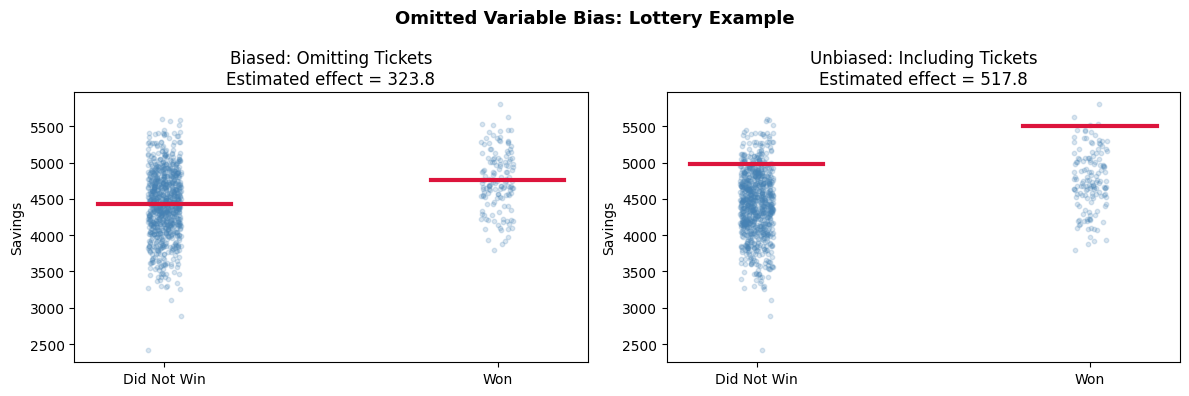

In [ ]:


# ── Simulate Lottery Data ──
# True causal model:
# Savings = α0 + α1·WinLottery + α2·Tickets + U
# α1 = 500 (true causal effect of winning)
# α2 = -200 (more tickets → lower income → lower savings)
# Cov(Win, Tickets) > 0 → OVB is negative → α1* underestimates α1

np.random.seed(42)
n = 1000

# Number of tickets (proxy for income — lower income buys more)
tickets = np.random.poisson(3, n)

# Winning is random conditional on tickets
win = np.array([np.random.binomial(1, min(t/20, 0.95)) for t in tickets])

# True savings model
U = np.random.randn(n) * 300
savings = 5000 + 500*win - 200*tickets + U

# ── Model 1: Omitting tickets (biased) ──
X_biased = win.reshape(-1, 1)
m_biased = LinearRegression().fit(X_biased, savings)

# ── Model 2: Including tickets (unbiased) ──
X_full = np.column_stack([win, tickets])
m_full = LinearRegression().fit(X_full, savings)

# ── Print Results ──
print("=" * 55)
print(f"  True causal effect of winning (α₁)  :  500")
print("=" * 55)
print(f"  Biased estimate   (omitting tickets) :  {m_biased.coef_[0]:.1f}")
print(f"  Unbiased estimate (including tickets):  {m_full.coef_[0]:.1f}")
print("=" * 55)

# Compute OVB analytically
alpha2 = m_full.coef_[1]
cov_ratio = np.cov(win, tickets)[0,1] / np.var(win)
print(f"\n  OVB = α₂ × Cov(Win, Tickets)/Var(Win)")
print(f"      = {alpha2:.1f} × {cov_ratio:.2f}")
print(f"      = {alpha2 * cov_ratio:.1f}")
print(f"\n  Biased estimate ≈ 500 + ({alpha2 * cov_ratio:.1f}) = {500 + alpha2*cov_ratio:.1f} ✓")

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, title, coef, intercept in zip(
    axes,
    ['Biased: Omitting Tickets', 'Unbiased: Including Tickets'],
    [m_biased.coef_[0], m_full.coef_[0]],
    [m_biased.intercept_, m_full.intercept_]
):
    ax.scatter(win + np.random.uniform(-0.05, 0.05, n),
               savings, alpha=0.2, s=10, color='steelblue')
    for w in [0, 1]:
        ax.plot([w-0.2, w+0.2],
                [intercept + coef*w]*2,
                color='crimson', linewidth=3)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Did Not Win', 'Won'])
    ax.set_ylabel('Savings')
    ax.set_title(f'{title}\nEstimated effect = {coef:.1f}')

plt.suptitle('Omitted Variable Bias: Lottery Example',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. OLS for Multiple Linear Regression

### Setup: Three Requirements

For OLS estimation of an MLR model, we need:

1. **Exogeneity**: $E[\mathbf{X}_i \varepsilon_i] = 0$ for all $i$
   - True *by definition* under a descriptive/predictive interpretation
   - A *substantive assumption* under a causal interpretation (justified by conditional independence / control variable argument)

2. **Finite second moments**: $E[\mathbf{X}\mathbf{X}'] < \infty$ — a technical condition, never a practical issue

3. **No perfect collinearity** in $\mathbf{X}$ — the key new requirement; discussed in detail below

### Properties Under These Conditions

Same as in SLR:

| Property | When it holds |
|---|---|
| **Consistency** | Always (under the three requirements) |
| **Unbiasedness** | If $E[Y \mid \mathbf{X}]$ is linear |
| **BLUE (Gauss-Markov)** | Linearity + i.i.d. + homoskedasticity |
| **Standard errors** | Same types as SLR (default / robust / clustered) |

### The OLS Estimator

Under these conditions, the population parameter satisfies:

$$\boldsymbol{\beta} = \left(E[\mathbf{X}\mathbf{X}']\right)^{-1} E[\mathbf{X}Y]$$

which gives us the sample analogue — the OLS estimator:

$$\hat{\boldsymbol{\beta}}_n = \left(\frac{1}{n}\sum_{i=1}^n \mathbf{X}_i\mathbf{X}_i'\right)^{-1} \frac{1}{n}\sum_{i=1}^n \mathbf{X}_i Y_i$$

The critical piece is that $E[\mathbf{X}\mathbf{X}']$ must be **invertible**. Here's the intuition: the OLS estimator works by asking *"how does $Y$ move when $X_j$ moves, holding everything else fixed?"* If two regressors are perfectly collinear, they always move together — you can never hold one fixed while varying the other, so the question has no answer. Mathematically, the matrix has no inverse, and $\hat{\boldsymbol{\beta}}_n$ cannot be computed.

## Perfect Collinearity

Perfect collinearity occurs when one regressor is an exact linear combination of the others — i.e., there exists a $\mathbf{C} \neq 0$ such that $\mathbf{C}'\mathbf{X} = 0$, or equivalently:

$$X_j = c_0 + c_1 X_1 + \dots + c_{j-1} X_{j-1} + c_{j+1} X_{j+1} + \dots + c_k X_k$$

### The Dummy Variable Trap

The classic example: suppose we want to study the effect of immigration status and define:

$$N_i = \begin{cases} 1 & \text{if born in US} \\ 0 & \text{otherwise} \end{cases} \qquad I_i = \begin{cases} 1 & \text{if born outside US} \\ 0 & \text{otherwise} \end{cases}$$

Everyone is either native-born or immigrant, so $N_i + I_i = 1$ always — meaning $N_i = 1 - I_i$. Including both plus a constant creates perfect collinearity:

$$Y = \beta_0 + \beta_1 N_i + \beta_2 I_i + \varepsilon \quad \leftarrow \text{cannot be estimated}$$

**Fix:** drop one indicator and keep the other as the **omitted category**:

$$Y = \beta_0 + \beta_1 I_i + \varepsilon \quad \leftarrow \text{native-born is the reference group}$$

### General Rule

Whenever you have indicator variables for $k$ mutually exclusive groups (ethnic groups, age ranges, education levels, ...), you must either:
- Include $k-1$ indicators and a constant (one omitted category), **or**
- Include all $k$ indicators and **no constant**

Either works. Doing both causes the dummy variable trap.

=== Perfect Collinearity Demo ===
Coefficients: [1.51212329 0.954566   0.55755729]

Matrix rank with both dummies + constant: 2
Matrix rank with one dummy + constant:   2


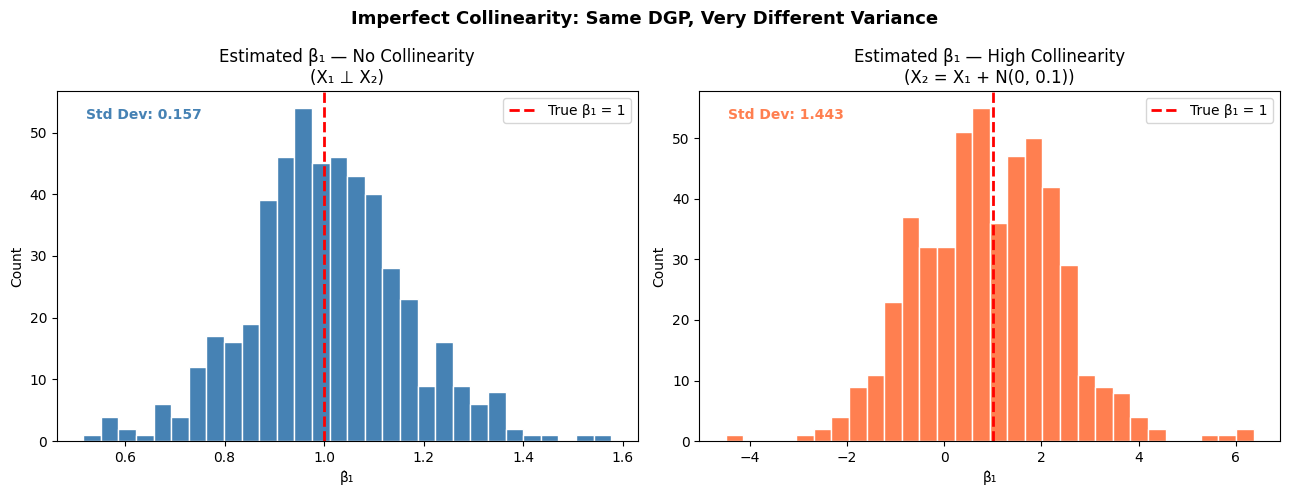

In [ ]:

np.random.seed(42)
n, n_sims = 50, 500

# --- Perfect collinearity demo ---
print("=== Perfect Collinearity Demo ===")
X1_demo = np.random.normal(5, 1, 100)
N = (X1_demo > 5).astype(int)   # native-born dummy
I = 1 - N                        # immigrant dummy — perfectly collinear with N

X_trap = sm.add_constant(np.column_stack([N, I]))
y_demo = 2 + 0.5 * N + np.random.normal(0, 1, 100)

try:
    model_trap = sm.OLS(y_demo, X_trap).fit()
    print("Coefficients:", model_trap.params)
except Exception as e:
    print("Error:", e)

print("\nMatrix rank with both dummies + constant:", np.linalg.matrix_rank(X_trap))
print("Matrix rank with one dummy + constant:  ",
      np.linalg.matrix_rank(sm.add_constant(N)))

# --- Simulation: No collinearity ---
beta1_no_coll = []
for _ in range(n_sims):
    X1 = np.random.normal(5, 1, n)
    X2 = np.random.normal(5, 1, n)          # X1 ⊥ X2
    Y  = X1 + X2 + np.random.normal(0, 1, n)
    X  = sm.add_constant(np.column_stack([X1, X2]))
    beta1_no_coll.append(sm.OLS(Y, X).fit().params[1])

# --- Simulation: High collinearity ---
beta1_high_coll = []
for _ in range(n_sims):
    X1 = np.random.normal(5, 1, n)
    X2 = X1 + np.random.normal(0, 0.1, n)   # X2 ≈ X1
    Y  = X1 + X2 + np.random.normal(0, 1, n)
    X  = sm.add_constant(np.column_stack([X1, X2]))
    beta1_high_coll.append(sm.OLS(Y, X).fit().params[1])

# --- Side-by-side histograms ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(beta1_no_coll, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(1, color='red', linestyle='--', linewidth=2, label='True β₁ = 1')
axes[0].set_title('Estimated β₁ — No Collinearity\n(X₁ ⊥ X₂)', fontsize=12)
axes[0].set_xlabel('β̂₁'); axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].annotate(f'Std Dev: {np.std(beta1_no_coll):.3f}',
                 xy=(0.05, 0.92), xycoords='axes fraction', fontsize=10,
                 color='steelblue', fontweight='bold')

axes[1].hist(beta1_high_coll, bins=30, color='coral', edgecolor='white')
axes[1].axvline(1, color='red', linestyle='--', linewidth=2, label='True β₁ = 1')
axes[1].set_title('Estimated β₁ — High Collinearity\n(X₂ = X₁ + N(0, 0.1))', fontsize=12)
axes[1].set_xlabel('β̂₁'); axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].annotate(f'Std Dev: {np.std(beta1_high_coll):.3f}',
                 xy=(0.05, 0.92), xycoords='axes fraction', fontsize=10,
                 color='coral', fontweight='bold')

plt.suptitle('Imperfect Collinearity: Same DGP, Very Different Variance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## What To Do About Imperfect Collinearity

Imperfect collinearity doesn't prevent estimation — but it inflates variance. The distribution of $\hat{\beta}_1$ is still centered on the truth, but any given sample can produce a wildly inaccurate estimate. What to do depends on your goal:

### Causal Inference

If a collinear variable is a necessary control — i.e., you need it to argue that $E[\mathbf{X}_i \varepsilon_i] = 0$ — **you have to include it**. The high variance is not a modeling error; it is the honest reflection of how little information your data contains about the effect of interest once the controls are accounted for. There is no shortcut.

### Prediction

If the goal is prediction, the tradeoff is less clear. Excluding a collinear predictor loses some information but reduces variance and sensitivity to any particular sample. Useful guides:
- **Out-of-sample MSE** — compare models on a held-out validation set
- **Automated feature selection** — methods like LASSO penalize model complexity and can select among correlated predictors for you (more on this later)

---

## Key Takeaways — OLS for MLR

| | |
|---|---|
| **Three requirements** | Exogeneity, finite second moments, no perfect collinearity |
| **OLS estimator** | $\hat{\boldsymbol{\beta}}_n = \left(\frac{1}{n}\sum \mathbf{X}_i\mathbf{X}_i'\right)^{-1}\frac{1}{n}\sum \mathbf{X}_i Y_i$ — requires $E[\mathbf{X}\mathbf{X}']$ to be invertible |
| **Perfect collinearity** | Makes estimation impossible — most commonly triggered by the dummy variable trap |
| **Dummy variable trap** | With $k$ mutually exclusive groups: include $k-1$ dummies + constant, or all $k$ dummies + no constant |
| **Imperfect collinearity** | Estimation still works, but variance blows up — estimates remain unbiased but highly sensitive to the sample |
| **Causal context** | Must keep the collinear control — the high variance is the truth, not a mistake |
| **Prediction context** | Dropping collinear predictors may improve out-of-sample performance — use validation MSE or LASSO to decide |

---

Same zoom room today for office hrs 